In [12]:
from pathlib import Path
import re
import warnings
from __future__ import annotations

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from rasterio.windows import transform as window_transform


# ============================================================
# KONFIGURACJA
# ============================================================

# TIF_DIR = Path(r"C:\kody\hakajton\sentinel2_downloads_ddz_07-09_2018\wybrane")
#TIF_DIR = Path(r"C:\kody\hakajton\inne_dane\wybrane")
TIF_DIR = Path(r"C:\kody\hakajton\inne_dane_2")
TIF_GLOB = "sentinel2_*.tif"

out_path = f"C:\kody\hakajton\inne_dane_2\punkty"
POINTS_SHP = Path(f"{out_path}\wybrane_punkty.shp")
OUT_CSV = Path(f"{out_path}\summary.csv")

# Promień liczony w pikselach rastra wejściowego.
# Jeśli piksel ma 20 m:
# 3 = ok. 60 m, 5 = ok. 100 m.
RADIUS_PIXELS = 3

# Jeżeli chcesz użyć konkretnego pola jako ID punktu.
# Przy agregacji 1 obraz -> 1 wartość nie jest to krytyczne.
POINT_ID_FIELD = None

# Czy zapisać również średnie wartości pasm.
INCLUDE_BAND_MEANS = True

# Jeżeli wartości w TIFF-ach są reflektancją 0-10000, ustaw 1/10000.
# Jeżeli są już 0-1, ustaw 1.0.
# Dla samych indeksów skala nie zmienia wyniku, ale ma znaczenie dla średnich pasm.
REFLECTANCE_SCALE = 1 / 10000.0

# ----------------------------------------------------------------
# KLUCZOWE: mapowanie numerów bandów w Twoim wielopasmowym TIFF-ie.
#
# Przykładowy układ:
# 1  B01
# 2  B02
# 3  B03
# 4  B04
# 5  B05
# 6  B06
# 7  B07
# 8  B08
# 9  B8A
# 10 B09
# 11 B11
# 12 B12
# 13 SCL, jeśli został dołączony
#
# Jeżeli Twój plik ma inną kolejność, zmień poniższe numery.
# ----------------------------------------------------------------

BAND_INDEX = {
    "B01": 1,
    "B02": 2,
    "B03": 3,
    "B04": 4,
    "B05": 5,
    "B06": 6,
    "B07": 7,
    "B08": 8,
    "B8A": 9,
    "B09": 10,
    "B11": 11,
    "B12": 12,

    # Jeżeli SCL nie ma w pliku, ustaw None.
    "SCL": None,
}

S2_L2A_REFLECTANCE_BANDS = [
    "B01", "B02", "B03", "B04", "B05", "B06",
    "B07", "B08", "B8A", "B09", "B11", "B12"
]

# Klasy SCL odrzucane z analizy:
# 0 no data
# 1 saturated / defective
# 2 dark area pixels / topographic shadows
# 3 cloud shadows
# 8 cloud medium probability
# 9 cloud high probability
# 10 thin cirrus
# 11 snow / ice
INVALID_SCL_CLASSES = {0, 1, 2, 3, 8, 9, 10, 11}


# ============================================================
# FUNKCJE
# ============================================================

def parse_dates_from_filename(path: Path) -> tuple[str | None, str | None]:
    """
    Dla nazw typu:
    sentinel2_20180704_20180707.tif
    zwraca ('2018-07-04', '2018-07-07')
    """
    m = re.search(r"sentinel2_(\d{8})_(\d{8})", path.stem)
    if not m:
        return None, None

    def fmt(s: str) -> str:
        return f"{s[:4]}-{s[4:6]}-{s[6:8]}"

    return fmt(m.group(1)), fmt(m.group(2))


def normalized_difference(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Liczy (a - b) / (a + b), z obsługą NaN i dzielenia przez zero."""
    with np.errstate(divide="ignore", invalid="ignore"):
        denom = a + b
        out = (a - b) / denom
        out[np.abs(denom) < 1e-12] = np.nan
    return out.astype("float32")


def read_points(points_shp: Path, target_crs, point_id_field: str | None) -> gpd.GeoDataFrame:
    """Czyta shapefile i transformuje punkty do CRS rastra."""
    gdf = gpd.read_file(points_shp)

    if gdf.empty:
        raise ValueError("Shapefile nie zawiera geometrii.")

    if gdf.crs is None:
        raise ValueError("Shapefile nie ma zdefiniowanego CRS.")

    gdf = gdf.to_crs(target_crs)

    if point_id_field and point_id_field in gdf.columns:
        gdf["_point_id"] = gdf[point_id_field].astype(str)
    else:
        gdf["_point_id"] = [str(i) for i in range(len(gdf))]

    gdf["_point_geom"] = gdf.geometry.apply(
        lambda geom: geom if geom.geom_type == "Point" else geom.centroid
    )

    return gdf


def make_window_for_point(row: int, col: int, radius_px: int, height: int, width: int) -> Window | None:
    row_min = max(row - radius_px, 0)
    row_max = min(row + radius_px + 1, height)

    col_min = max(col - radius_px, 0)
    col_max = min(col + radius_px + 1, width)

    if row_min >= row_max or col_min >= col_max:
        return None

    return Window(
        col_off=col_min,
        row_off=row_min,
        width=col_max - col_min,
        height=row_max - row_min,
    )


def make_union_window_and_mask(points_gdf: gpd.GeoDataFrame, src, radius_px: int):
    """
    Tworzy jedno okno i maskę będącą sumą okrągłych buforów pikselowych wokół punktów.

    Dzięki temu dla danego obrazu dostajesz jedną agregację po wszystkich pikselach
    znajdujących się w promieniu od zadanych punktów.
    """
    point_windows = []
    point_centers = []

    for _, point in points_gdf.iterrows():
        geom = point["_point_geom"]
        center_row, center_col = src.index(geom.x, geom.y)

        if (
            center_row < 0 or center_row >= src.height or
            center_col < 0 or center_col >= src.width
        ):
            warnings.warn(f"Punkt {point['_point_id']} leży poza rastrem. Pomijam.")
            continue

        win = make_window_for_point(
            row=center_row,
            col=center_col,
            radius_px=radius_px,
            height=src.height,
            width=src.width,
        )

        if win is None:
            continue

        point_windows.append(win)
        point_centers.append((center_row, center_col))

    if not point_windows:
        raise RuntimeError("Żaden punkt nie znajduje się w zasięgu obrazu.")

    min_row = min(int(w.row_off) for w in point_windows)
    min_col = min(int(w.col_off) for w in point_windows)
    max_row = max(int(w.row_off + w.height) for w in point_windows)
    max_col = max(int(w.col_off + w.width) for w in point_windows)

    union_window = Window(
        col_off=min_col,
        row_off=min_row,
        width=max_col - min_col,
        height=max_row - min_row,
    )

    union_mask = np.zeros((max_row - min_row, max_col - min_col), dtype=bool)

    for win, (center_row, center_col) in zip(point_windows, point_centers):
        row_start = int(win.row_off)
        row_end = int(win.row_off + win.height)
        col_start = int(win.col_off)
        col_end = int(win.col_off + win.width)

        rows = np.arange(row_start, row_end)[:, None]
        cols = np.arange(col_start, col_end)[None, :]

        dist2 = (rows - center_row) ** 2 + (cols - center_col) ** 2
        local_mask = dist2 <= radius_px ** 2

        rr0 = row_start - min_row
        rr1 = row_end - min_row
        cc0 = col_start - min_col
        cc1 = col_end - min_col

        union_mask[rr0:rr1, cc0:cc1] |= local_mask

    return union_window, union_mask, len(point_windows)


def read_band(src, band_name: str, window: Window, scale_reflectance: bool = True) -> np.ndarray:
    """Czyta wskazany band z wielopasmowego TIFF-a."""
    band_idx = BAND_INDEX.get(band_name)

    if band_idx is None:
        raise ValueError(f"Band {band_name} ma ustawione None w BAND_INDEX.")

    if band_idx > src.count:
        raise ValueError(
            f"Band {band_name} wskazuje na indeks {band_idx}, "
            f"ale raster ma tylko {src.count} bandów."
        )

    arr = src.read(band_idx, window=window).astype("float32")

    nodata = src.nodata
    if nodata is not None:
        arr[arr == nodata] = np.nan

    # Zera w wycinkach Sentinel-2 często oznaczają nodata poza sceną.
    # Jeżeli u Ciebie zero jest poprawną reflektancją, usuń tę linię.
    if scale_reflectance:
        arr[arr <= 0] = np.nan
        arr *= REFLECTANCE_SCALE

    return arr


def masked_mean(arr: np.ndarray, mask: np.ndarray) -> float:
    vals = arr[mask]
    if vals.size == 0 or np.all(np.isnan(vals)):
        return np.nan
    return float(np.nanmean(vals))


def masked_median(arr: np.ndarray, mask: np.ndarray) -> float:
    vals = arr[mask]
    if vals.size == 0 or np.all(np.isnan(vals)):
        return np.nan
    return float(np.nanmedian(vals))


def masked_fraction(condition: np.ndarray, base_mask: np.ndarray) -> float:
    total = int(np.sum(base_mask))
    if total == 0:
        return np.nan
    return float(np.sum(condition & base_mask) / total)


def process_one_multiband_tif(tif_path: Path) -> dict:
    """Przetwarza jeden wielopasmowy GeoTIFF Sentinel-2."""
    print(f"Processing: {tif_path.name}")

    date_from, date_to = parse_dates_from_filename(tif_path)

    with rasterio.open(tif_path) as src:
        points_gdf = read_points(POINTS_SHP, src.crs, POINT_ID_FIELD)

        union_window, union_mask, n_points_inside = make_union_window_and_mask(
            points_gdf=points_gdf,
            src=src,
            radius_px=RADIUS_PIXELS,
        )

        pixel_size_x = abs(src.transform.a)
        pixel_size_y = abs(src.transform.e)

        # Pasma potrzebne do indeksów
        b03 = read_band(src, "B03", union_window)
        b04 = read_band(src, "B04", union_window)
        b08 = read_band(src, "B08", union_window)
        b8a = read_band(src, "B8A", union_window)
        b11 = read_band(src, "B11", union_window)

        # Indeksy liczone piksel po pikselu
        ndvi = normalized_difference(b08, b04)
        ndmi = normalized_difference(b8a, b11)
        mndwi = normalized_difference(b03, b11)

        # Maska jakości z SCL, jeżeli jest dostępna
        scl_band_idx = BAND_INDEX.get("SCL")

        if scl_band_idx is not None:
            scl = read_band(src, "SCL", union_window, scale_reflectance=False).astype("uint8")
            valid_scl_mask = ~np.isin(scl, list(INVALID_SCL_CLASSES))
            valid_mask = union_mask & valid_scl_mask
        else:
            scl = None
            valid_mask = union_mask

        n_selected = int(np.sum(union_mask))
        n_valid = int(np.sum(valid_mask))

        result = {
            "image_file": tif_path.name,
            "date_from_filename": date_from,
            "date_to_filename": date_to,
            "radius_pixels": RADIUS_PIXELS,
            "approx_radius_m_x": RADIUS_PIXELS * pixel_size_x,
            "approx_radius_m_y": RADIUS_PIXELS * pixel_size_y,
            "n_points_inside_image": n_points_inside,
            "n_selected_pixels": n_selected,
            "n_valid_pixels": n_valid,
            "valid_fraction": n_valid / n_selected if n_selected else np.nan,

            # Główne wyniki: średnia po pikselach
            "NDVI_mean": masked_mean(ndvi, valid_mask),
            "NDMI_mean": masked_mean(ndmi, valid_mask),
            "MNDWI_mean": masked_mean(mndwi, valid_mask),

            # Często warto mieć też medianę, bo jest odporniejsza na pojedyncze piksele odstające
            "NDVI_median": masked_median(ndvi, valid_mask),
            "NDMI_median": masked_median(ndmi, valid_mask),
            "MNDWI_median": masked_median(mndwi, valid_mask),
        }

        if scl is not None:
            result.update({
                "scl_water_fraction": masked_fraction(scl == 6, union_mask),
                "scl_vegetation_fraction": masked_fraction(scl == 4, union_mask),
                "scl_bare_soil_fraction": masked_fraction(scl == 5, union_mask),
                "scl_cloud_shadow_fraction": masked_fraction(scl == 3, union_mask),
                "scl_cloud_fraction": masked_fraction(np.isin(scl, [8, 9, 10]), union_mask),
                "scl_snow_ice_fraction": masked_fraction(scl == 11, union_mask),
            })

        if INCLUDE_BAND_MEANS:
            for band_name in S2_L2A_REFLECTANCE_BANDS:
                band_idx = BAND_INDEX.get(band_name)
                if band_idx is None or band_idx > src.count:
                    continue

                band_arr = read_band(src, band_name, union_window)
                result[f"{band_name}_mean"] = masked_mean(band_arr, valid_mask)
                result[f"{band_name}_median"] = masked_median(band_arr, valid_mask)

    return result


def main():
    tif_paths = sorted(TIF_DIR.glob(TIF_GLOB))

    if not tif_paths:
        raise FileNotFoundError(f"Nie znaleziono plików {TIF_GLOB} w folderze {TIF_DIR}")

    results = []

    for tif_path in tif_paths:
        try:
            results.append(process_one_multiband_tif(tif_path))
        except Exception as e:
            warnings.warn(f"Nie udało się przetworzyć {tif_path.name}: {e}")

    if not results:
        raise RuntimeError("Nie uzyskano żadnych wyników.")

    df = pd.DataFrame(results)
    df.to_csv(OUT_CSV, index=False, encoding="utf-8")

    print(f"\nZapisano wynik do: {OUT_CSV}")
    print(df)


if __name__ == "__main__":
    main()

Processing: sentinel2_20180704_20180707.tif
Processing: sentinel2_20180713_20180716.tif
Processing: sentinel2_20180807_20180810.tif
Processing: sentinel2_20180828_20180831.tif

Zapisano wynik do: C:\kody\hakajton\inne_dane_2\punkty\summary.csv
                        image_file date_from_filename date_to_filename  \
0  sentinel2_20180704_20180707.tif         2018-07-04       2018-07-07   
1  sentinel2_20180713_20180716.tif         2018-07-13       2018-07-16   
2  sentinel2_20180807_20180810.tif         2018-08-07       2018-08-10   
3  sentinel2_20180828_20180831.tif         2018-08-28       2018-08-31   

   radius_pixels  approx_radius_m_x  approx_radius_m_y  n_points_inside_image  \
0              3          29.965096          29.969748                      1   
1              3          29.965096          29.969748                      1   
2              3          29.965096          29.969748                      1   
3              3          29.965096          29.969748       

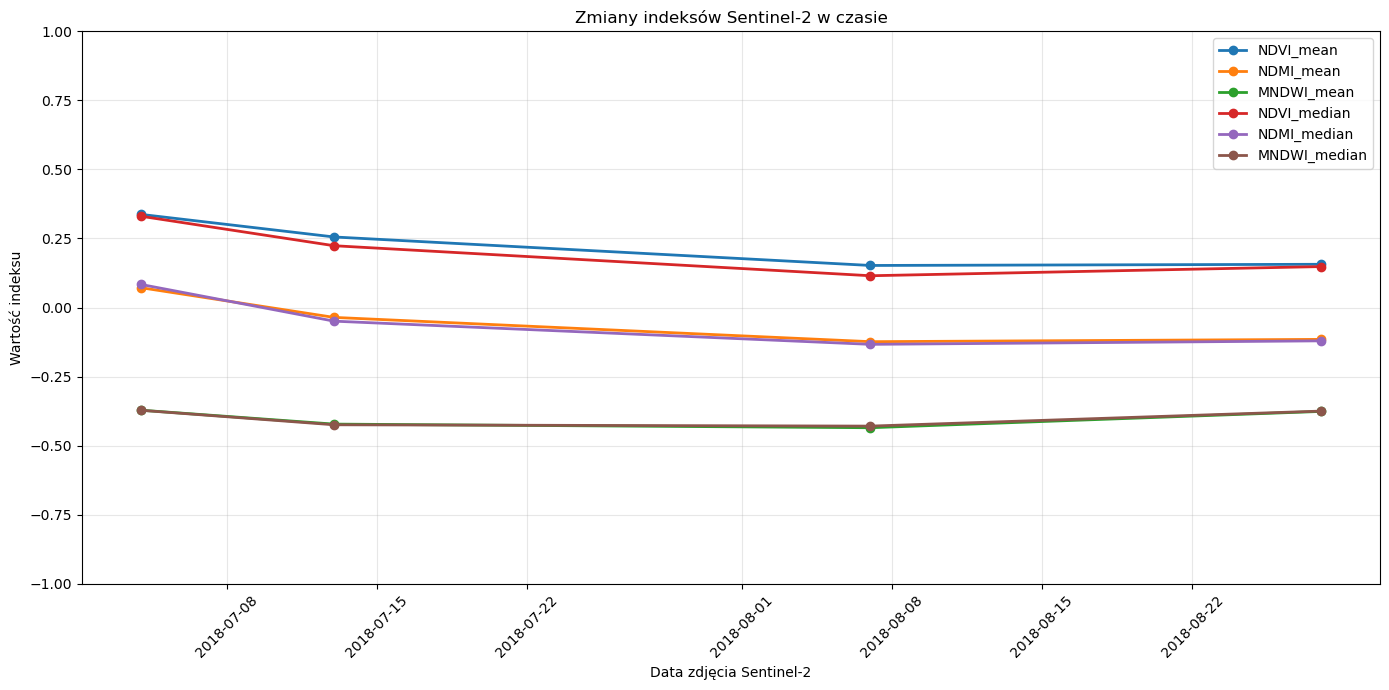

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytanie wyników
# df = pd.read_csv(r"C:\kody\hakajton\789\summary.csv")
df = pd.read_csv(r"C:\kody\hakajton\inne_dane_2\punkty\summary.csv")

# Zamiana daty na typ datetime
df["date"] = pd.to_datetime(df["date_from_filename"])

# Sortowanie po dacie
df = df.sort_values("date")

# Kolumny do narysowania
columns_to_plot = [
    "NDVI_mean",
    "NDMI_mean",
    "MNDWI_mean",
    "NDVI_median",
    "NDMI_median",
    "MNDWI_median",
]

# Wykres
plt.figure(figsize=(14, 7))

for col in columns_to_plot:
    if col in df.columns:
        plt.plot(
            df["date"],
            df[col],
            marker="o",
            linewidth=2,
            label=col,
        )

plt.ylim(-1, 1)
plt.xlabel("Data zdjęcia Sentinel-2")
plt.ylabel("Wartość indeksu")
plt.title("Zmiany indeksów Sentinel-2 w czasie")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()